## Introduction to JAX

In [1]:
# --- Imports ---
import numpy as np
import jax
import jax.numpy as jnp
import time
import matplotlib.pyplot as plt

jax.print_environment_info()

jax:    0.6.1
jaxlib: 0.6.1
numpy:  2.2.6
python: 3.13.3 | packaged by conda-forge | (main, Apr 14 2025, 20:44:03) [GCC 13.3.0]
device info: cpu-1, 1 local devices"
process_count: 1
platform: uname_result(system='Linux', node='fedora', release='6.15.9-201.fc42.x86_64', version='#1 SMP PREEMPT_DYNAMIC Sat Aug  2 11:37:34 UTC 2025', machine='x86_64')


### NumPy vs JAX NumPy ###

JAX provides a NumPy-like API via jax.numpy (jnp).
Most NumPy functions work with the same syntax, but JAX arrays can run on CPU, GPU, or TPU.

In [2]:
print("NumPy version:", np.__version__)
print("JAX version:", jax.__version__)

NumPy version: 2.2.6
JAX version: 0.6.1


In [3]:
# Arrays look the same but differ in backend and immutability
x_np = np.arange(5)
x_jax = jnp.arange(5)
print("NumPy array:", x_np)
print("JAX array:", x_jax)

# Operations are similar and interchangeable
print("np.sin(x_np):", np.sin(x_np))
print("jnp.sin(x_jax):", jnp.sin(x_jax))

NumPy array: [0 1 2 3 4]
JAX array: [0 1 2 3 4]
np.sin(x_np): [ 0.          0.84147098  0.90929743  0.14112001 -0.7568025 ]
jnp.sin(x_jax): [ 0.          0.84147096  0.9092974   0.14112    -0.7568025 ]


In [4]:
# ---  Arrays are immutable in JAX ---
# Unlike NumPy, JAX arrays are immutable.
# You cannot change elements in place (important for functional programming & reproducibility).
try:
    x_jax[0] = 99  # This will raise an error
except Exception as e:
    print("Immutability in JAX:", e)

# Instead, you must create a new array using functional updates with .at[]
x_jax_updated = x_jax.at[0].set(99)
print("Updated JAX array (functional update):", x_jax_updated)

Immutability in JAX: JAX arrays are immutable and do not support in-place item assignment. Instead of x[idx] = y, use x = x.at[idx].set(y) or another .at[] method: https://docs.jax.dev/en/latest/_autosummary/jax.numpy.ndarray.at.html
Updated JAX array (functional update): [99  1  2  3  4]


### Automatic Differentiation
JAX has built-in automatic differentiation with grad().

Let $f(x) = \sin(x) e^{-x}$. Compute the derivative of $f$ using jax.grad(f)

In [5]:
from jax import grad, value_and_grad

def f(x):
    return jnp.sin(x) * jnp.exp(-x)

f_prime = grad(f)

print("f(2.0) =", f(2.0))
print("f'(2.0) =", f_prime(2.0))

# You can compute value and gradient together using value_and_grad
total_val, grad_val = value_and_grad(f)(2.0)
print("Value and gradient at x=2.0:", total_val, grad_val)


f(2.0) = 0.12306002
f'(2.0) = -0.17937937
Value and gradient at x=2.0: 0.12306002 -0.17937937


In [6]:
# vmap automatically vectorizes a function across batch dimensions.
# Instead of writing explicit loops, you specify which axis to map over.
from jax import vmap

def h(x, y):
    return x * y + jnp.sin(x)

xs = jnp.arange(5.)
ys = jnp.arange(5.)

# Instead of looping over xs and ys, we apply vmap
ih_vectorized = vmap(h, in_axes=(0, 0))
print("Vectorized h(xs, ys):", ih_vectorized(xs, ys))


Vectorized h(xs, ys): [ 0.         1.841471   4.9092975  9.14112   15.243197 ]


When the function $f$ has multiple variables, `jax.grad` by default computes the derivative of $f$ with respect to the first argument (index 0). To differentiate with respect to another argument, use the `argnums` option in `jax.grad`.

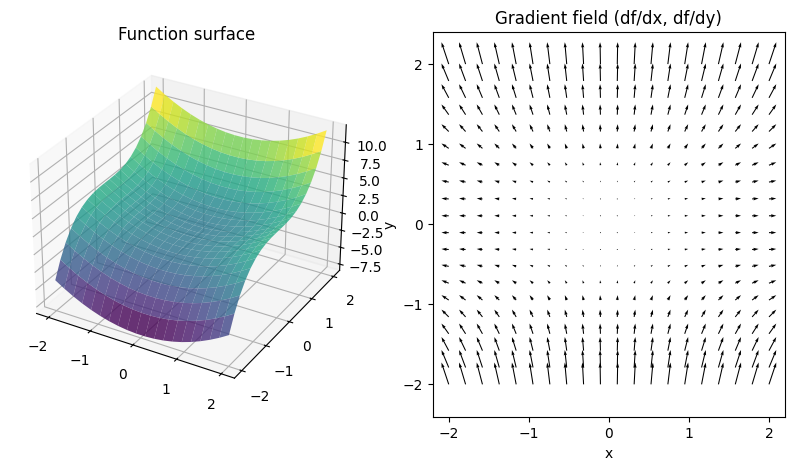

In [7]:
# Define a simple two-variable function
def f(x, y):
    return x**2 + y**3

# Compute gradients
df_dx = grad(f, argnums=0)
df_dy = grad(f, argnums=1)

# Create a meshgrid for visualization
x = jnp.linspace(-2, 2, 20)
y = jnp.linspace(-2, 2, 20)
X, Y = jnp.meshgrid(x, y)

# Vectorize gradient computations
grad_x = vmap(lambda xx, yy: df_dx(xx, yy))(X.ravel(), Y.ravel())
grad_y = vmap(lambda xx, yy: df_dy(xx, yy))(X.ravel(), Y.ravel())

# Plot the function surface with gradient vectors
fig = plt.figure(figsize=(10, 5))

# Surface plot
ax = fig.add_subplot(1, 2, 1, projection="3d")
Z = f(X, Y)
ax.plot_surface(X, Y, Z, cmap="viridis", alpha=0.8)
ax.set_title("Function surface")

# Gradient vector field
ax2 = fig.add_subplot(1, 2, 2)
ax2.quiver(X.ravel(), Y.ravel(), grad_x, grad_y, angles="xy")
ax2.set_title("Gradient field (df/dx, df/dy)")
ax2.set_xlabel("x")
ax2.set_ylabel("y")
ax2.axis("equal")

plt.show()

### JIT Compilation
JIT (just-in-time) compilation speeds up functions by compiling them with XLA.
First call includes compilation overhead, later calls are very fast.


Let’s compare performance between NumPy, JAX eager execution, and JAX JIT.


In [8]:

N = 5_000_000

# NumPy benchmark
x_np = np.random.rand(N).astype(np.float32)
start = time.time()
res_np = np.dot(x_np, x_np)
end = time.time()
print("NumPy dot time:", end - start, "seconds")

# JAX (without JIT)
x_jax = jnp.array(x_np)
start = time.time()
res_jax = jnp.dot(x_jax, x_jax).block_until_ready()  # ensure sync with device
end = time.time()
print("JAX (eager) dot time:", end - start, "seconds")

# JAX (with JIT)
@jax.jit
def jax_dot(x):
    return jnp.dot(x, x)

# First call includes compilation
start = time.time()
res_jax_jit = jax_dot(x_jax).block_until_ready()
end = time.time()
print("JAX JIT dot (first call, includes compile):", end - start, "seconds")

# Second call is fast (compilation is cached)
start = time.time()
res_jax_jit = jax_dot(x_jax).block_until_ready()
end = time.time()
print("JAX JIT dot (second call, cached):", end - start, "seconds")


NumPy dot time: 0.0011355876922607422 seconds
JAX (eager) dot time: 0.023540735244750977 seconds
JAX JIT dot (first call, includes compile): 0.02297687530517578 seconds
JAX JIT dot (second call, cached): 0.005352020263671875 seconds


### Randomness in JAX
JAX uses functional, explicit random number generation.
You must manage PRNG keys explicitly (no hidden global RNG state like NumPy).

In [9]:

key = jax.random.PRNGKey(0)
rand_nums = jax.random.normal(key, (3,))
print("Random numbers (JAX):", rand_nums)

# You split keys to generate reproducible independent streams
key, subkey = jax.random.split(key)
print("Next random numbers with split key:", jax.random.uniform(subkey, (3,)))



Random numbers (JAX): [ 1.6226422   2.0252647  -0.43359444]
Next random numbers with split key: [0.00729382 0.02089119 0.5814265 ]



#### Summary ####
    - JAX arrays behave like NumPy arrays but are immutable (functional updates only)
    - JAX integrates automatic differentiation with grad and value_and_grad
    - JIT compilation provides massive speedups after the first call
    - vmap enables automatic vectorization across batch dimensions
    - Randomness requires explicit PRNG key management
    - Performance: JAX with JIT can significantly outperform NumPy, especially on accelerators (GPU/TPU)